In [2]:
import os

import torch
from pycocotools.coco import COCO  # COCODataset 사용 위한 API

from torch.utils.data import Dataset, DataLoader  # Pytorch의 데이터셋 관련
from torchvision import transforms  # 전처리모듈

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np


In [2]:

## 데이터 준비
DATA_DIR = './_data/'
# DATA_DIR = '../_data/coco/'

## 이미지 전처리 관련 인스턴스
## - 이미지 텐서화 및 타입 설정
## - Faster R-CNN 모델에서는 다양한 이미지 입력 가능 ==> Resizing 하지 않음!
transform = transforms.Compose(
    [
        transforms.PILToTensor(),  ## PIL.ToTensor 사용 ToTensor와는 다름.
        ## PIL의 Image 객체를 텐서화
        transforms.ConvertImageDtype(dtype=torch.float)  ## Image 텐서 타입 설정
    ]
)


NameError: name 'transforms' is not defined

In [4]:
annotations = os.path.join('./data',
                                   "Annotation",
                                   f"coco_astrophysics.json")

In [ ]:

## -------------------------------------------------------------
## 클래스이름 : X_rayDataset
## 부모클래스 : Dataset
## -------------------------------------------------------------
class X_rayDataset(Dataset):
    ## ---------------------------------------------------------
    ## - 필수 오버라이딩 메서드
    ## ---------------------------------------------------------
    ## ---------------------------------------------------------
    ## 메서드이름 : __init__
    ## 매개변수들
    # root: 데이터가 존재하는 경로
    # train : 학습용 또는 검증용 식별 위한
    # transform 이미지 전처리 인스턴스 지점
    ## ---------------------------------------------------------
    def __init__(self, root, train, transform=None):
        super().__init__()
        ## 실제 이미지 경로
        directory = "train" if train else "val"

        ## 이미지 내의 존재 객체 정보 추출.
        annotations = os.path.join(root,
                                   "Annotation",
                                   f"coco_astrophysics.json")

        self.coco = COCO(annotations)
        ## train/val_annotation.json 읽어서 dict로 저장 
        # - self.dataset
        # - self.anns 이미지별 부가정보들
        # - self.cats 데이터셋의 카테고리 정보
        # - self.imgs 이미지

        self.iamge_path = os.path.join(root, directory)
        self.transform = transform

        # 클래스 내부에서만 사용되는 메서드 호출 self.~~
        self.categories = self._get_categories()  # 해당 데이터셋의 카테고리 IDX_TO_NAME
        self.data = self._load_data()
            
            
    ## ---------------------------------------------------------
    ## 메서드이름: __getitem__
    ## 매개변수들: 특정 데이터 인덱스
    ## 반환결과값: 인덱스에 해당하는 이미지와 타겟 반환
    ## ---------------------------------------------------------
    def __getitem__(self, index):
        image, target = self.data[index]
        if self.transform:
            image = self.transform(image)
        return image, target

    ## ---------------------------------------------------------
    ## 메서드이름: __len__
    ## 매개변수들: 없음
    ## 반환결과값: 데이터 갯수 반환
    ## ---------------------------------------------------------
    def __len__(self):
        return len(self.data)

    ## ---------------------------------------------------------
    ## - 사용자 정의 메서드
    ## ---------------------------------------------------------
    ## ---------------------------------------------------------
    ## 메서드기능: 정수 맵핑 카테고리 반환 내장 메서드
    ## 메서드이름: _get_categories
    ## 매개변수들: 없음
    ## 반환결과값: 정수 맵핑된 카테고리 Dict
    ## ---------------------------------------------------------
    def _get_categories(self):
        categories = {0: "background"}
        for category in self.coco.cats.values():
            categories[category["id"]] = category["name"]
        return categories

    ## ---------------------------------------------------------
    ## 메서드기능: 데이터셋 이미지와 이미지 정보 타겟 반환 내장 메서드
    ## 메서드이름: _load_data
    ## 매개변수들: 없음
    ## 반환결과값: 이미지데이터와 타겟을 리스트로 담고 있는 리스트
    ## ---------------------------------------------------------
    def _load_data(self):
        data = []
        for _id in self.coco.imgs:
            ## 이미지 데이터 로딩
            file_name = self.coco.loadImgs(_id)[0]["file_name"]
            image_path = os.path.join(self.iamge_path, file_name)

            # raw 데이터 추출.
            image = Image.open(image_path).convert("RGB")

            ## 이미지 내 객체의 위치와 이미지 클래스 저장
            boxes, labels = [], []
            ## 이미지에 연동된 어노테이션 리스트 추출
            anns = self.coco.loadAnns(self.coco.getAnnIds(_id))
            ## 이미지 내에 객체 위치와 카테고리 정보 추출
            for ann in anns:
                x, y, w, h = ann["bbox"]
                boxes.append([x, y, x + w, y + h])

                labels.append(ann["category_id"])
            ## 이미지의 타겟 정보 즉, 아이디, 박스위치, 클래스 정보
            target = {
                "image_id": torch.LongTensor([_id]),
                "boxes": torch.FloatTensor(boxes),
                "labels": torch.LongTensor(labels)
            }
            data.append([image, target])
        return data


In [63]:
## 배치 데이터 생성 함수
## ---------------------------------------------------------
## 함수기능 : 개별 샘플을 미니배치로 결합하는 역할
## 함수이름 : collator
## 매개변수 : 배치크기
## 반환결과 : 배치크기만큼 연결된 데이터
## ---------------------------------------------------------
def collator(batch):
    return tuple(zip(*batch))

In [ ]:
ROOT = './data/'
## 학습용, 테스트용 데이터셋 생성
trainDS = X_rayDataset(DATA_DIR, root=ROOT, train=True, transform=transform)
testDS = X_rayDataset(DATA_DIR, root=ROOT, train=False, transform=transform)

loading annotations into memory...


FileNotFoundError: [Errno 2] No such file or directory: './_data/annotations\\train_annotations.json'

In [45]:
## 클래스 변환 Dict 생성
IDX_TO_CATEGORY = trainDS.categories
print(IDX_TO_CATEGORY)
## 학습용 테스트용 데이터 확인
print(f'[trainDS] 개수 : {len(trainDS)}개 ')
print(f'[testDS] 개수  : {len(testDS)}개 ')
## 학습용 데이터셋에서 이미지 1개
imgTS, targetDict = trainDS[0]  ## <== __getitem__(indx)
print(imgTS.shape, targetDict.keys())

{0: 'background', 1: 'cat', 2: 'dog'}
[trainDS] 개수 : 2431개 
[testDS] 개수  : 181개 
torch.Size([3, 479, 640]) dict_keys(['image_id', 'boxes', 'labels'])


lx, ly, w, h => (337, 244, 66, 67)


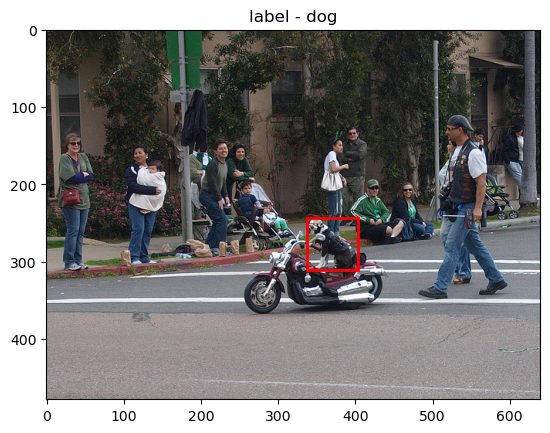

In [46]:

# - 라벨 정보 추출
label = targetDict['labels'].item()

# - 객체 위치 정보 추출
lx, ly, rx, ry = [round(data.item()) for data in targetDict['boxes'].reshape(-1)]
w, h = rx - lx, ry - ly

print(f'lx, ly, w, h => {lx, ly, w, h}')
## 시각화 및 바운딩 박스
plt.imshow(imgTS.permute(1, 2, 0))
plt.title(f'label - {IDX_TO_CATEGORY[label]}')

## 바운딩 박스 추가
ax = plt.gca()  #- get current axis
ax.add_patch(patches.Rectangle((lx, ly), w, h, color='red', linewidth=2, fill=False))

plt.show()

In [47]:
## 모델 관련 모듈 로딩
from torchvision.models import vgg16, VGG16_Weights
from torchvision.models.detection import RetinaNet
from torchvision.models._utils import IntermediateLayerGetter


In [ ]:

## --------------------------------------------------------------
## 모델 관련 설정들
## --------------------------------------------------------------
## - Backbone Network 관련
WEIGHTS = VGG16_Weights.DEFAULT
# Get VGG16 features
backbone = vgg16(weights=WEIGHTS).features
# 특징 추출 레이어 정의 (FPN 사용 시)
# VGG16의 경우, 풀링(pooling) 블록 이후의 일반적인 레이어들이 FPN을 위한 특징 추출에 사용됩니다.
# 이름들은 Sequential 특징 블록에 있는 모듈들의 이름과 일치합니다.
# 원하는 레이어의 정확한 이름/인덱스를 찾으려면 백본 구조를 확인해야 할 수 있습니다 (예: 백본 출력).
# 풀링 이전의 마지막 몇몇 Conv2d 레이어 또는 특정 풀링 레이어 이후의 레이어 인덱스를 사용하는 예시입니다. FPN이 특정 해상도 레벨을 기대하기 때문입니다.
# VGG 아키텍처의 일반적인 특징에 기반하여, 인덱스 16, 23, 30 근처의 레이어들이 컨볼루션 블록 끝 부분 또는 풀링 레이어 이후에 해당될 수 있습니다.
# VGG를 FPN과 함께 사용할 때 일반적인 방법은 마지막 몇몇 풀링 레이어 이전의 특징을 사용하는 것입니다.
# 시연을 위해 몇 가지 그럴듯한 레이어 인덱스를 선택했습니다. 실제 인덱스는 약간 다를 수 있습니다.

return_layers = {'23': '0', '25': '1', '27': '2', '29': '3', '30': '4'} # Example indices

# Using IntermediateLayerGetter to get features from specified layers
backbone = IntermediateLayerGetter(backbone, return_layers=return_layers)

# Define the number of output channels for the backbone's features.
# For VGG16 features used with FPN, the number of channels for the selected layers is typically 512.
backbone.out_channels = 512

In [50]:

## 학습관련 설정 값
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 10
TBATCH_SIZE = 4
VBATCH_SIZE = 1

In [51]:


# Initialize the RetinaNet model
# num_classes = 3 (background, dog, cat)
MODEL = RetinaNet(
    backbone=backbone,
    num_classes=3  # +1 for background in some definitions, but torchvision's RetinaNet handles it
).to(DEVICE)


## 데이터셋 관련 인스턴스 생성
TRAIN_DL = DataLoader(trainDS, batch_size=TBATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator)
TEST_DL = DataLoader(testDS, batch_size=VBATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator)
print(TRAIN_DL)

In [52]:

from torch import optim

params = [p for p in MODEL.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [53]:

## 학습 진행
for epoch in range(1): # Reduced epochs for demonstration
    cost = 0.0
    MODEL.train() # Set model to training mode
    for idx, (images, targets) in enumerate(TRAIN_DL):
        ## GPU에 이미지와 타겟 정보 위치
        images = list(image.to(DEVICE) for image in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        if idx == 4: # Reduced iterations for demonstration
             break

        ## 모델 학습 ==> 이미지와 이미지 내의 객체 정보 ( 클래스, 박스) 전달
        loss_dict = MODEL(images, targets)
        ## - 모델 구성에서 계산된 손실값의 합계
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        cost += losses.item() # Use .item() to get the scalar value of the loss

    lr_scheduler.step()
    cost = cost / (idx + 1) # Calculate average cost over the iterations
    print(f"Epoch : {epoch + 1:4d}, Cost : {cost:.3f}")


Epoch :    1, Cost : 1.432


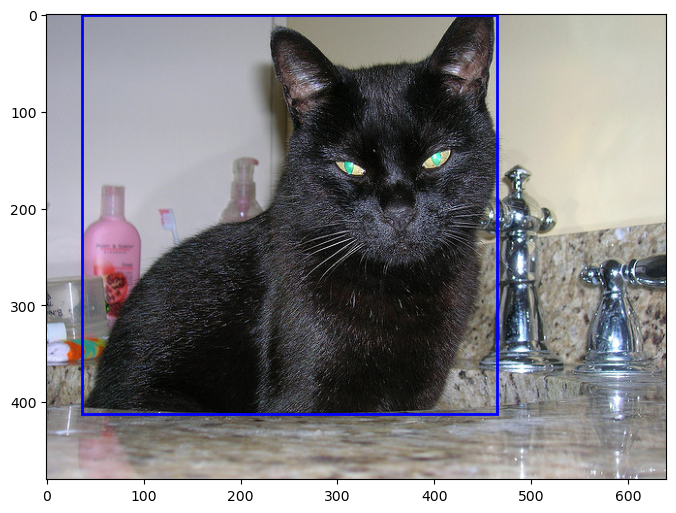

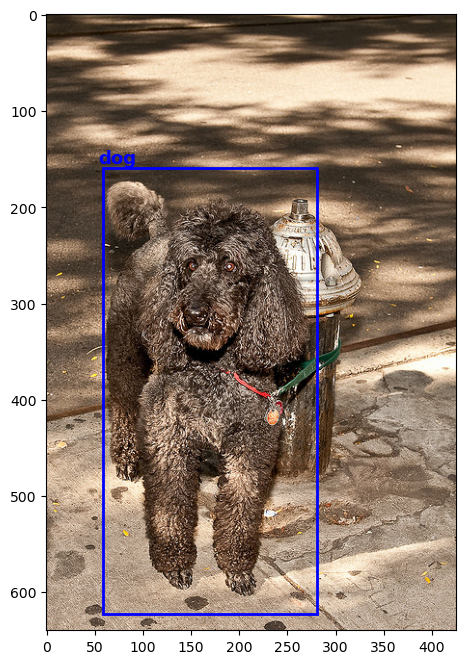

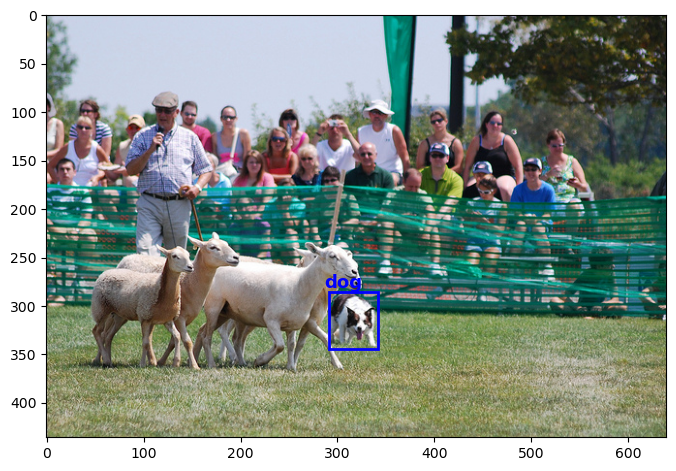

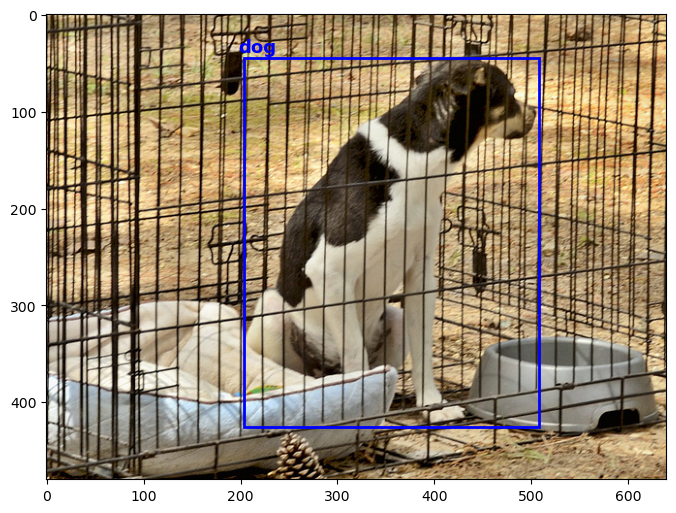

In [ ]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from torchvision.transforms.functional import to_pil_image

## 객체에 박스 그리기.
def draw_bbox(ax, box, text, color):
    ax.add_patch(
        plt.Rectangle(
            xy=(box[0], box[1]),
            width=box[2] - box[0],
            height=box[3] - box[1],
            fill=False,
            edgecolor=color,
            linewidth=2,
        )
    )
    #객체 위치에 라벨 달기
    ax.annotate(
        text=text,
        xy=(box[0] - 5, box[1] - 5),
        color=color,
        weight="bold",
        fontsize=13,
    )
 
 
## 검증진행
## 예측 결과에 대한 신뢰도. 0.5 이상이면 중간 이상의 신뢰도
threshold = 0.5
categories = testDS.categories
with torch.no_grad():
    MODEL.eval()
    idx = 0
    for images, targets in TEST_DL:
        idx += 1
        if idx == 5:
            break
        # 예측진행
        images = [image.to(DEVICE) for image in images] ## GPU적용. cpu면 없어도됨
        
        outputs = MODEL(images)
        # 각 이미지에 대한 예측 결과 반환
        ## -> boxes : 예측된 경계상자 좌표
        ## -> labels: 예측 박스의 클래스 인덱스
        ## -> scores : 예측 박스에 대한 신뢰도(확률) 점수, 값의 범위는 0.0~1.0
        ## 예측 객체 위치, 라벨, 점수 저장 변수들
        boxes = outputs[0]["boxes"].to(DEVICE).numpy()
        labels = outputs[0]["labels"].to(DEVICE).numpy()
        scores = outputs[0]["scores"].to(DEVICE).numpy()
        
        
        boxes = boxes[scores >= threshold].astype(np.int32)
        labels = labels[scores >= threshold]
        scores = scores[scores >= threshold]

        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(1, 1, 1)
        plt.imshow(to_pil_image(images[0]))

        for box, label, score in zip(boxes, labels, scores):
            draw_bbox(ax, box, f"{categories[label]} - {score:.4f}", "red")

        tboxes = targets[0]["boxes"].numpy()
        tlabels = targets[0]["labels"].numpy()
        for box, label in zip(tboxes, tlabels):
            draw_bbox(ax, box, f"{categories[label]}", "blue")
            
        plt.show()

In [60]:
## 검증 진행에 따른 성능평가
## -> 정확도, 정밀도, 재현율


import numpy as np
from pycocotools.cocoeval import COCOeval


with torch.no_grad():
    MODEL.eval()
    coco_detections = []
    
    idx = 0
    for images, targets in TEST_DL:
        idx += 1
        if idx == 5:
            break
        images = [img.to(DEVICE) for img in images]
        outputs = MODEL(images)
        ## 예측값
        
        for i in range(len(targets)):
            ## 정답
            image_id = targets[i]["image_id"].data.cpu().numpy().tolist()[0]
            
            ## 예측값
            boxes = outputs[i]["boxes"].data.cpu().numpy()
            boxes[:, 2] = boxes[:, 2] - boxes[:, 0]
            boxes[:, 3] = boxes[:, 3] - boxes[:, 1]
            scores = outputs[i]["scores"].data.cpu().numpy()
            labels = outputs[i]["labels"].data.cpu().numpy()

            for instance_id in range(len(boxes)):
                box = boxes[instance_id, :].tolist()
                prediction = np.array(
                    [
                        image_id,
                        box[0],
                        box[1],
                        box[2],
                        box[3],
                        float(scores[instance_id]),
                        int(labels[instance_id]),
                    ]
                )
                coco_detections.append(prediction)

    ##예측정보 저장
    coco_detections = np.asarray(coco_detections)
    coco_gt = TEST_DL.dataset.coco()                  ## 정답
    coco_dt = coco_gt.loadRes(coco_detections)      ## 예측
    
    coco_evaluator = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_evaluator.evaluate()
    coco_evaluator.accumulate()
    coco_evaluator.summarize()
    
    ## 성능평가
    ## 정답박스와 예측박스 비교방식 ==> IOU
    ## p 533
    

TypeError: 'COCO' object is not callable